In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")
df = pd.read_csv("../data/raw/transactions.csv", parse_dates=["timestamp"])
print(df.shape)
df.head()

(1000, 9)


,transaction_id,timestamp,amount,merchant,category,country,hour,is_fraud,fraud_type
0,TXN923927,2024-01-01 07:53:00,41.02,ExxonMobil,gas,US,7,0,NaN
1,TXN642752,2024-01-01 12:25:00,125.22,Whole Foods,grocery,US,12,0,NaN
2,TXN722518,2024-01-01 14:06:00,13.61,Subway,restaurant,US,14,0,NaN
3,TXN594681,2024-01-02 08:32:00,60.24,Walmart,grocery,US,8,0,NaN
4,TXN938769,2024-01-02 11:14:00,102.99,ExxonMobil,gas,US,11,0,NaN


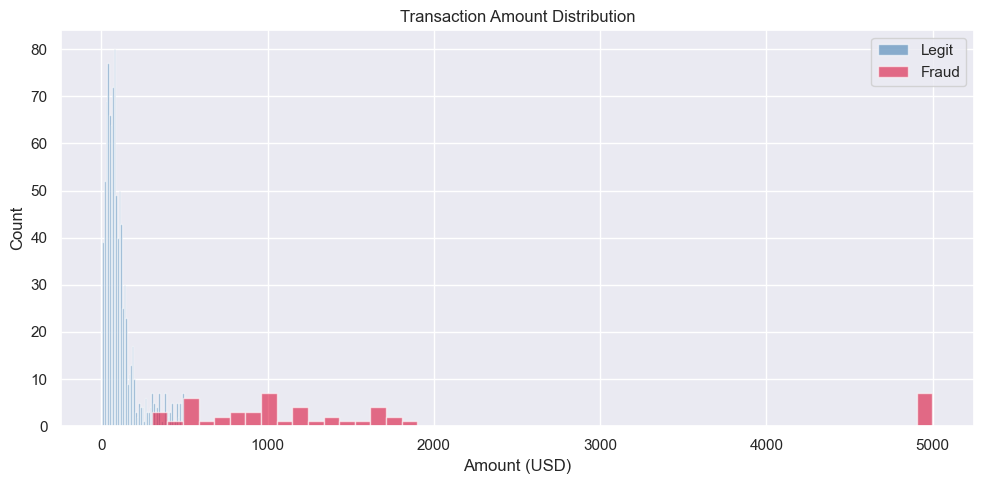

In [2]:
fig, ax = plt.subplots(figsize=(10, 5))
for label, color in [(0, "steelblue"), (1, "crimson")]:
    subset = df[df["is_fraud"] == label]["amount"]
    ax.hist(subset, bins=50, alpha=0.6, color=color,
            label="Legit" if label == 0 else "Fraud")
ax.set_title("Transaction Amount Distribution")
ax.set_xlabel("Amount (USD)")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.savefig("../outputs/figures/amount_distribution.png", dpi=150)
plt.show()

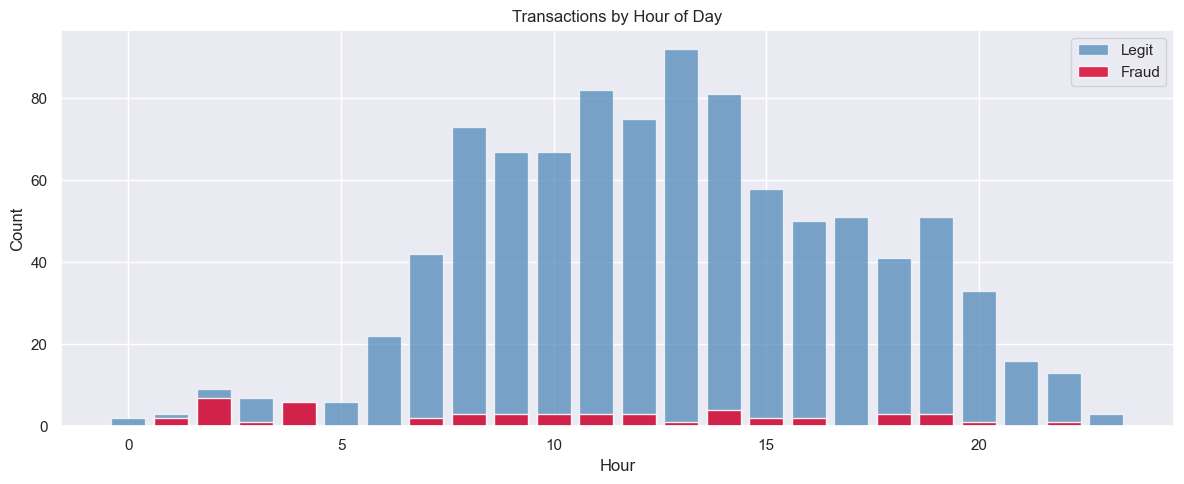

In [3]:
fig, ax = plt.subplots(figsize=(12, 5))
fraud_by_hour = df[df["is_fraud"] == 1]["hour"].value_counts().sort_index()
legit_by_hour = df[df["is_fraud"] == 0]["hour"].value_counts().sort_index()
ax.bar(legit_by_hour.index, legit_by_hour.values, color="steelblue", alpha=0.7, label="Legit")
ax.bar(fraud_by_hour.index, fraud_by_hour.values, color="crimson", alpha=0.9, label="Fraud")
ax.set_title("Transactions by Hour of Day")
ax.set_xlabel("Hour")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.savefig("../outputs/figures/hourly_pattern.png", dpi=150)
plt.show()

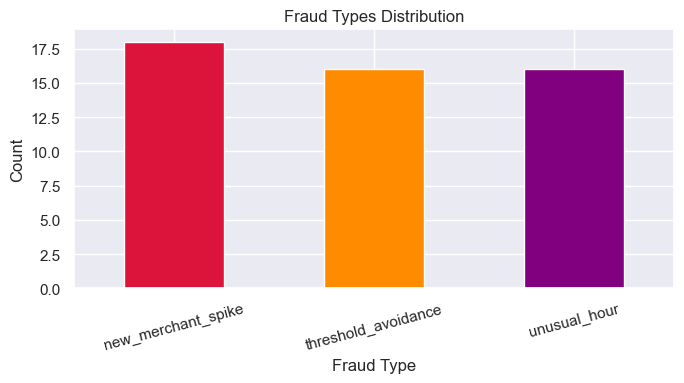

In [4]:
fraud_types = df[df["is_fraud"] == 1]["fraud_type"].value_counts()
fig, ax = plt.subplots(figsize=(7, 4))
fraud_types.plot(kind="bar", color=["crimson", "darkorange", "purple"], ax=ax)
ax.set_title("Fraud Types Distribution")
ax.set_xlabel("Fraud Type")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.savefig("../outputs/figures/fraud_types.png", dpi=150)
plt.show()